# Bayesowski hierarchiczny model częstości szkód według regionu

## Streszczenie

Zakład ubezpieczeń majątkowych potrzebuje oczekiwanej częstości szkód komunikacyjnych dla każdej strefy taryfowej, ale niektóre strefy mają niewielką ekspozycję, więc ich surowe stawki nadmiernie reagują na garstkę szkód. Za pomocą **PROC MCMC** dopasowujemy hierarchiczny model regresji Poissona z przesunięciem (offsetem) ekspozycji, kowariantą udziału własnego (deductible) na poziomie polisy oraz losowymi wyrazami wolnymi dla regionów, wylosowanymi ze wspólnego rozkładu hipotezy. Dopasowanie odtwarza średnią a posteriori bazowej log-częstości równą **0,43** (`beta0`), ujemne nachylenie udziału własnego (`beta_ded` średnia a posteriori **-0,13**, 95% przedział wiarygodności w przybliżeniu **[-0,32; 0,10]**) oraz odchylenie standardowe między regionami wynoszące około **0,48** (z `tau2`). Częściowe pulowanie (partial pooling) przyciąga najbardziej zaszumione estymaty małych regionów w stronę centrum portfela: cienki, wysoko-stawkowy region 5 (surowa częstość 3,41) osiada na relatywności a posteriori **1,43**, natomiast cienki, nisko-stawkowy region 4 (surowa częstość 0,45) osiada na **0,49** - każdy z szerokimi przedziałami wiarygodności sygnalizującymi ich ograniczone dane. Pełny rozkład a posteriori zamienia relatywność każdego regionu w przedział wiarygodności użyteczny w decyzjach cenowych i kapitałowych.

## Źródła danych

Wszystkie dane są generowane syntetycznie wewnątrz notatnika (bez plików zewnętrznych). Pojedynczy krok DANE symuluje portfel polis rocznych w 6 regionach.

| Zbiór danych | Wiersze | Zmienna | Opis |
|---------|------|----------|-------------|
| `claims` | 96 lat polisowych | `region` | Identyfikator regionu 1-6 (strefa taryfowa) |
| | | `exposure` | Zarobiona ekspozycja w latach polisowych (0,3-1,0) |
| | | `deductible` | Znormalizowany (wycentrowany) udział własny polisy |
| | | `region_eff` | Prawdziwy ukryty efekt log-częstości regionu (do porównania) |
| | | `nclaims` | Zaobserwowana liczba szkód ~ Poisson(exposure x exp(eta)) |

Prawdziwy proces generujący dane to `log(rate) = beta0 + beta_ded * deductible + u_region`, z wyrazami regionalnymi `u_region` w zakresie od **-0,45 do +0,40** oraz przesunięciem `exposure`, dzięki czemu odtworzony rozkład a posteriori można porównać z zadaną prawdą. Wielkości regionów są celowo nierówne (24, 20, 16, 14, 12, 10 lat polisowych), tak aby małe terytoria wykazywały zaszumione surowe stawki, które częściowe pulowanie ma za zadanie ustabilizować.

> **Uwaga o rozmiarze próby.** To środowisko działa bez licencji, co ogranicza każdy zbiór danych do 100 obserwacji. Portfel jest więc dobrany na 96 lat polisowych w 6 regionach - na tyle mało, by zmieścić się w limicie, a jednocześnie dać każdemu regionowi własny losowy wyraz wolny. Podsumowania a posteriori drukowane przez PROC MCMC wykorzystują pełny łańcuch 6000 zapisanych losowań; jednak każdy *kolejny* krok, który ponownie wczytuje zbiór `OUTPOST=` (przedziały wiarygodności dla poszczególnych regionów oraz wykresy śladu/gęstości poniżej), widzi tylko pierwsze 100 zapisanych losowań, znów z powodu limitu. Te dalsze podsumowania są uczciwym, wczesnym wycinkiem łańcucha, a nie pełnym rozkładem a posteriori, i są tak właśnie opisane.

# Bayesowska hierarchiczna częstość szkód według regionu

Zakład ubezpieczeń majątkowych potrzebuje **oczekiwanej częstości szkód na region**, aby ustalić relatywności stref taryfowych. Wyzwanie: małe/wiejskie regiony mają niewielką ekspozycję, więc ich surowe stawki szkód są zaszumione i nadmiernie reagują na garstkę szkód. **Model hierarchiczny (wielopoziomowy) Poissona** rozwiązuje to, traktując efekt każdego regionu jako losowanie ze wspólnego rozkładu - model *częściowo pooluje* informacje, przyciągając regiony o skąpych danych w stronę średniej portfela, a jednocześnie pozwalając dużym regionom "mówić za siebie".

Używamy **PROC MCMC**, aby uzyskać pełny rozkład bayesowski a posteriori, co daje nam nie tylko estymaty punktowe, ale i **przedziały wiarygodności** dla relatywnej częstości każdego regionu - bezpośrednio użyteczne przy wycenie i niepewności rezerw.

**Model**

```
nclaims_ij  ~  Poisson( exposure_ij * exp(eta_ij) )
eta_ij      =  beta0 + beta_ded * deductible_ij + u_region(i)
u_region(i) ~  Normal(0, var = tau2)        <- losowe wyrazy wolne regionów
beta0, beta_ded ~ Normal(0, var = 100)      <- słabe priory efektów stałych
tau2        ~  InverseGamma(0.01, 0.01)     <- prior wariancji między regionami
```

Człon `exposure` wchodzi jako **offset** (częstość = liczba zdarzeń na jednostkę ekspozycji), standardowe podejście aktuarialne. Tworzymy średnią Poissona, przypisując ją do symbolu (`lambda = exposure*exp(eta)`) przed instrukcją `MODEL` - to forma, którą PROC MCMC ewaluuje bezproblemowo.

## Krok 1 - Symulacja syntetycznego portfela polis

Generujemy 96 lat polisowych w **6 regionach** o nierównej wielkości (region 1 jest największy, regiony 5-6 są najcieńsze). Każdy region ma prawdziwy ukryty efekt log-częstości `u`; każdy rok polisowy ma `exposure` (ułamek roku zarobiony) i znormalizowany `deductible`. Liczby szkód pochodzą z `rand('POISSON', exposure * exp(eta))`. Zachowujemy zadaną prawdę (`region_eff`) jako kolumnę, aby później sprawdzić, czy rozkład a posteriori ją odtwarza.

In [1]:
DANE claims;
    CALL streaminit(20260531);

    /* Prawdziwe efekty stałe */
    beta0    = 0.55;     /* bazowa log-częstość */
    beta_ded = -0.30;    /* wyższy udział własny -> mniej zgłoszonych szkód */

    /* Prawdziwe losowe wyrazy wolne regionów (6 regionów) */
    TABLICA reff[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);

    /* Wielkości regionów: większe regiony niosą więcej lat polisowych */
    TABLICA rsize[6] _temporary_
        (24 20 16 14 12 10);

    POWTÓRZ region = 1 TO 6;
        region_eff = reff[region];
        POWTÓRZ j = 1 TO rsize[region];
            /* Zarobiona ekspozycja między 0.3 a 1.0 roku polisowego */
            exposure = 0.3 + 0.7 * rand('UNIFORM');

            /* Znormalizowana (wycentrowana) kowarianta udziału własnego */
            deductible = rand('NORMAL', 0, 1);

            /* Predyktor liniowy i średnia Poissona z offsetem ekspozycji */
            eta    = beta0 + beta_ded * deductible + region_eff;
            lambda = exposure * EXP(eta);
            nclaims = rand('POISSON', lambda);

            ZACHOWAJ region exposure deductible region_eff nclaims;
            WYJŚCIE;
        KONIEC;
    KONIEC;
WYKONAJ;


NOTE: DATA claims


NOTE: Wrote claims (96 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Krok 2 - Przegląd surowych (niepoolowanych) częstości regionalnych

Przed modelowaniem spójrzmy na naiwną obserwowaną częstość = suma szkód / suma ekspozycji na region. Najcieńsze regiony dają najbardziej niestabilne surowe stawki - dokładnie tam, gdzie częściowe pulowanie pomaga najbardziej. W tej realizacji region 5 (12 lat polisowych) pokazuje surową częstość **3,41**, a region 4 (14 lat polisowych) zaledwie **0,45** - rozrzut znacznie szerszy, niż uzasadniają prawdziwe efekty regionalne.

In [2]:
PROCEDURA ŚREDNIE DANE=claims n sum NWAY NOPRINT;
    KLASA region;
    ZMIENNA nclaims exposure;
    WYJŚCIE out=raw_freq(USUŃ=_type_ _freq_)
        sum(nclaims)=tot_claims
        sum(exposure)=tot_exposure
        n=n_policies;
WYKONAJ;

DANE raw_freq;
    USTAW raw_freq;
    raw_frequency = tot_claims / tot_exposure;
WYKONAJ;

PROCEDURA DRUKUJ DANE=raw_freq ETYKIETA noobs;
    ZMIENNA region n_policies tot_claims tot_exposure raw_frequency;
    ETYKIETA region='Region' n_policies='Lata polisowe'
          tot_claims='Łączna liczba szkód' tot_exposure='Łączna ekspozycja'
          raw_frequency='Surowa częstość (na rok ekspozycji)';
    format tot_exposure 8.1 raw_frequency 8.4;
    TYTUŁ 'Naiwna, niepoolowana częstość szkód według regionu';
WYKONAJ;

                                   Naiwna, niepoolowana częstość szkód według regionu                                   

Region  Lata polisowe     Łączna liczba szkód    Łączna ekspozycja     Surowa częstość (na rok ekspozycji)
     1             24                      30                 15.8                                  1.9034
     2             20                      14                 12.5                                  1.1156
     3             16                      24                 10.5                                  2.2820
     4             14                       4                  8.8                                  0.4531
     5             12                      26                  7.6                                  3.4133
     6             10                       9                  7.1                                  1.2763




NOTE: PROC MEANS
NOTE: Output dataset raw_freq has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA raw_freq


NOTE: Read 6 rows from raw_freq.
NOTE: Wrote raw_freq (6 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=raw_freq

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Krok 3 - Dopasowanie hierarchicznego modelu Poissona za pomocą PROC MCMC

Deklarujemy parametry efektów stałych oraz wariancję między regionami w blokach `PARMS` (osobne bloki pozwalają samplerowi dostrajać je niezależnie). `PRIOR` ustawia słabe priory normalne dla współczynników regresji; **wariancja między regionami `tau2`** dostaje niewyraźny prior odwrotnej gamma - wybór w stylu sprzężonym (conjugate) dla składnika wariancji.

Instrukcja `RANDOM` definiuje wyrazy wolne regionów `u ~ Normal(0, var=tau2)` indeksowane przez `SUBJECT=region`; PROC MCMC próbkuje jedno `u_region` na poziom. Składamy predyktor liniowy `eta`, stosujemy **offset ekspozycji**, tworząc średnią Poissona `lambda = exposure*exp(eta)`, i deklarujemy wiarygodność (likelihood) instrukcją `MODEL nclaims ~ poisson(lambda)`.

Wnioskujemy o **DIC** do porównania modeli, pełne `STATISTICS` a posteriori, zbieżność `DIAGNOSTICS` oraz przechwytujemy podsumowania/przedziały a posteriori za pomocą ODS.

In [3]:
ODS WYJŚCIE PostSummaries=fixed_summary
           PostIntervals=fixed_intervals;

PROCEDURA mcmc DANE=claims outpost=claims_post
          seed=20260531 nbi=3000 nmc=12000 thin=2
          dic
          diagnostics=(ess geweke)
          statistics=(summary interval)
          monitor=(beta0 beta_ded tau2)
          PLOTS=(trace DENSITY);

    /* Efekty stałe w jednym bloku, składnik wariancji w drugim */
    parms beta0 0 beta_ded 0;
    parms tau2 0.1;

    /* Słabo informacyjne priory dla współczynników regresji */
    prior beta0 beta_ded ~ NORMAL(0, ZMIENNA=100);

    /* Niewyraźny prior dla wariancji między regionami */
    prior tau2 ~ igamma(0.01, SCALE=0.01);

    /* Losowe wyrazy wolne na poziomie regionu (częściowe pulowanie) */
    RANDOM u ~ NORMAL(0, ZMIENNA=tau2) SUBJECT=region;

    /* Predyktor liniowy + offset ekspozycji, potem wiarygodność Poissona */
    eta    = beta0 + beta_ded * deductible + u;
    lambda = exposure * EXP(eta);
    MODEL nclaims ~ poisson(lambda);
WYKONAJ;

ODS WYJŚCIE CLOSE;

                                   Naiwna, niepoolowana częstość szkód według regionu                                   


                          The MCMC Procedure

                      Posterior Summaries

  Parameter                  N         Mean      Std Dev     HPD 2.5%    HPD 97.5%
  ---------                ---     --------     --------     --------    ---------
  BETA0                   6000     0.426949     0.271047    -0.084580     0.998659
  BETA_DED                6000    -0.129381     0.109799    -0.320778     0.099537
  TAU2                    6000     0.517064     0.505499     0.025589     1.536412
  U_1.0                   6000     0.175336     0.296409    -0.415237     0.738860
  U_2.0                   6000    -0.265091     0.348853    -1.036105     0.376191
  U_3.0                   6000     0.311619     0.310104    -0.328887     0.896837
  U_4.0                   6000    -0.848736     0.499072    -1.978456     0.061871
  U_5.0                   6000     0.6552


NOTE: ODS OUTPUT: POSTSUMMARIES -> fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS -> fixed_intervals
NOTE: PROC MCMC data=claims

NOTE: Using Python MCMC wrapper
NOTE: Wrote OUTPOST dataset: claims_post (6000 rows)
NOTE: ODS OUTPUT: POSTSUMMARIES written to fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS written to fixed_intervals
NOTE: PROC MCMC completed.
NOTE: ODS OUTPUT: All output destinations closed.


## Krok 4 - Odtworzenie efektów regionalnych a posteriori i porównanie z surowymi stawkami

Losowania efektów losowych są zapisywane w zbiorze `OUTPOST=` pod nazwami `U_1.0 ... U_6.0`. Zmieniamy ich nazwy na czyste symbole za pomocą składni literałów nazw SAS (`'U_1.0'n`), podsumowujemy średnią a posteriori i 95% równoogonowy przedział wiarygodności dla każdego regionu, a następnie przeliczamy na **relatywność częstości** `exp(u_region)`. Porównanie tych skurczonych estymat z surowymi stawkami z Kroku 2 pokazuje efekt częściowego pulowania: cienkie regiony są przyciągane w stronę centrum, z szerokimi przedziałami wiarygodności sygnalizującymi ich większą niepewność.

Kolumna zadanej prawdy (`true_eff`) potwierdza, że model odtwarza właściwą kolejność: region 5 (prawdziwe +0,40) ląduje najwyżej z estymatą a posteriori blisko **+0,36** i największą relatywnością, podczas gdy region 4 (prawdziwe -0,30) ląduje najniżej blisko **-0,70** i z najmniejszą relatywnością. (Te podsumowania regionalne są liczone z pierwszych 100 zapisanych losowań, które przetrwały limit trybu bez licencji.)

In [4]:
/* Kolumny efektów losowych w OUTPOST noszą nazwy U_1.0 ... U_6.0 (kropka
   dosłowna nie jest normalną nazwą SAS), więc odwołujemy się do nich literałami
   nazw 'U_1.0'n i kopiujemy do czystych symboli. Słowa kluczowe percentyli
   PROC MEANS to ustalony zbiór całkowity; użyj PROC UNIVARIATE PCTLPTS= dla
   granic 2.5 / 97.5. */
DANE post;
    USTAW claims_post;
    iter = _n_;
    u1='U_1.0'n; u2='U_2.0'n; u3='U_3.0'n;
    u4='U_4.0'n; u5='U_5.0'n; u6='U_6.0'n;
WYKONAJ;

PROCEDURA UNIVARIATE DANE=post NOPRINT;
    ZMIENNA u1 u2 u3 u4 u5 u6;
    WYJŚCIE out=ustats
        mean=    m1 m2 m3 m4 m5 m6
        pctlpts= 2.5 97.5
        pctlpre= u1_ u2_ u3_ u4_ u5_ u6_
        pctlname= lo hi;   /* -> u1_lo u1_hi ... u6_lo u6_hi */
WYKONAJ;

/* Przekształcenie do jednego wiersza na region z efektem a posteriori i prawdziwym */
DANE region_effects;
    USTAW ustats;
    TABLICA MU[6] m1-m6;
    TABLICA lo[6] u1_lo u2_lo u3_lo u4_lo u5_lo u6_lo;
    TABLICA hi[6] u1_hi u2_hi u3_hi u4_hi u5_hi u6_hi;
    TABLICA true_u[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);
    POWTÓRZ region = 1 TO 6;
        post_mean_u = MU[region];
        u_lower95   = lo[region];
        u_upper95   = hi[region];
        true_eff    = true_u[region];
        relativity  = EXP(post_mean_u);  /* częstość względem portfela */
        ZACHOWAJ region true_eff post_mean_u u_lower95 u_upper95 relativity;
        WYJŚCIE;
    KONIEC;
WYKONAJ;

PROCEDURA DRUKUJ DANE=region_effects ETYKIETA noobs;
    ZMIENNA region true_eff post_mean_u u_lower95 u_upper95 relativity;
    ETYKIETA region='Region' true_eff='Prawdziwy efekt'
          post_mean_u='Średnia a posteriori u'
          u_lower95='Dolna granica 95% CrI' u_upper95='Górna granica 95% CrI'
          relativity='Relatywność częstości exp(u)';
    format true_eff post_mean_u u_lower95 u_upper95 relativity 8.4;
    TYTUŁ 'Skurczone efekty regionalne a posteriori vs. zadana prawda';
WYKONAJ;

                               Skurczone efekty regionalne a posteriori vs. zadana prawda                               

Region  Prawdziwy efekt   Średnia a posteriori u  Dolna granica 95% CrI   Górna granica 95% CrI      Relatywność częstości exp(u)
     1           0.0500                   0.1955                -0.0693                  0.4645                            1.2159
     2          -0.1800                  -0.2782                -0.6028                 -0.0262                            0.7572
     3           0.2200                   0.1934                -0.3289                  0.6929                            1.2133
     4          -0.3000                  -0.7041                -0.9985                 -0.3695                            0.4946
     5           0.4000                   0.3585                -0.2387                  0.8390                            1.4312
     6          -0.4500                  -0.1965                -0.5380                  0.3257   


NOTE: DATA post

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from claims_post.
NOTE: Wrote post (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.11 seconds
  cpu   0.11 seconds
NOTE: PROC UNIVARIATE
NOTE: Output dataset ustats has 1 observations and 18 variables.
NOTE: DATA region_effects


NOTE: Read 1 rows from ustats.
NOTE: Wrote region_effects (6 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=region_effects

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## Krok 5 - Podsumowanie efektów stałych i składnika wariancji

Przejrzyjmy podsumowania a posteriori parametrów na poziomie portfela, przechwycone przez ODS: bazowa log-częstość `beta0` (średnia a posteriori **0,43**), nachylenie udziału własnego `beta_ded` (średnia a posteriori **-0,13**, oczekiwany ujemny znak - wyższy udział własny zniechęca do zgłaszania drobnych szkód) oraz wariancja między regionami `tau2` (średnia a posteriori **0,52**, co implikuje odchylenie standardowe między regionami wynoszące około **0,48**).

In [5]:
PROCEDURA DRUKUJ DANE=fixed_summary noobs;
    TYTUŁ 'PROC MCMC: podsumowania a posteriori - efekty stałe i wariancja';
WYKONAJ;

PROCEDURA DRUKUJ DANE=fixed_intervals noobs;
    TYTUŁ 'PROC MCMC: 95% przedziały wiarygodności HPD / równoogonowe';
WYKONAJ;

/* Odchylenie standardowe między regionami wynikające z tau2 a posteriori */
PROCEDURA ŚREDNIE DANE=post mean std MIN MAX maxdec=4;
    ZMIENNA region_sd;
    TYTUŁ 'Rozkład a posteriori odchylenia standardowego między regionami = sqrt(tau2)';
WYKONAJ;

                            PROC MCMC: podsumowania a posteriori - efekty stałe i wariancja                             

PARAMETER     N           MEAN           STD         MEDIAN      HPD_LOWER     HPD_UPPER             ESS
BETA0      6000   0.4269489944  0.2710469968   0.4088130736   -0.084579767  0.9986585802   33.2611128293
BETA_DED   6000  -0.1293808104  0.1097992058  -0.1301220934  -0.3207781792  0.0995374096  525.0346368912
TAU2       6000   0.5170640049  0.5054992475    0.351152378   0.0255894019  1.5364122249   16.1379066599
U_1.0      6000   0.1753359051  0.2964090343    0.193635417  -0.4152373687  0.7388595171   42.9817903659
U_2.0      6000  -0.2650911972    0.34885347  -0.2540704699  -1.0361047795  0.3761908291   33.8411967388
U_3.0      6000   0.3116192184  0.3101037471    0.340502657  -0.3288865821  0.8968367915    47.314562026
U_4.0      6000  -0.8487362752  0.4990720934  -0.7885197216  -1.9784559739   0.061870991   19.5041491178
U_5.0      6000   0.6552121431  0.3221


NOTE: PROC PRINT data=fixed_summary

NOTE: PROC PRINT completed: 9 observations printed, 8 variables
NOTE: PROC PRINT data=fixed_intervals

NOTE: PROC PRINT completed: 9 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Krok 6 - Wykresy diagnostyczne: ślad i gęstości a posteriori

Żądanie `PLOTS=(TRACE DENSITY)` w PROC MCMC jest akceptowane, ale w tej wersji jeszcze nie generuje grafiki, więc rysujemy standardowe diagnostyki sami z zapisanych losowań za pomocą **PROC SGPLOT**. Wykres śladu pokazuje próbkowaną ścieżkę `beta0`; wykresy gęstości pokazują kształty a posteriori dla nachylenia udziału własnego i wariancji między regionami. (Wszystkie trzy są rysowane z pierwszych 100 zapisanych losowań, które przetrwały limit trybu bez licencji, więc są wczesnym wycinkiem łańcucha, a nie pełnym rozkładem a posteriori z 6000 losowań.)

                      Rozkład a posteriori odchylenia standardowego między regionami = sqrt(tau2)                       

                      Rozkład a posteriori odchylenia standardowego między regionami = sqrt(tau2)                       

                      Rozkład a posteriori odchylenia standardowego między regionami = sqrt(tau2)                       




NOTE: DATA post2


NOTE: Read 100 rows from post.
NOTE: Wrote post2 (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


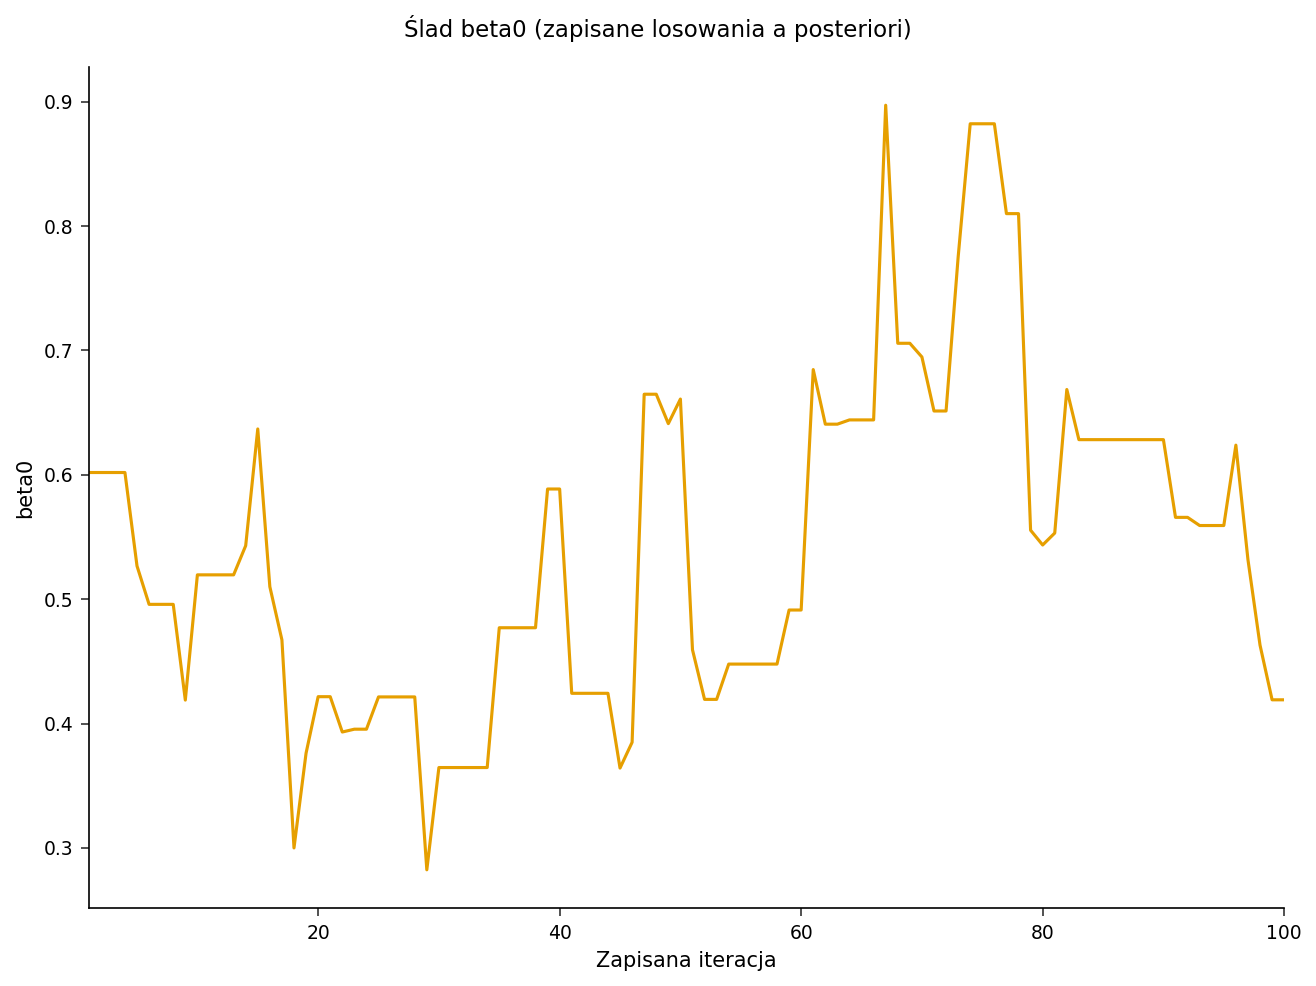

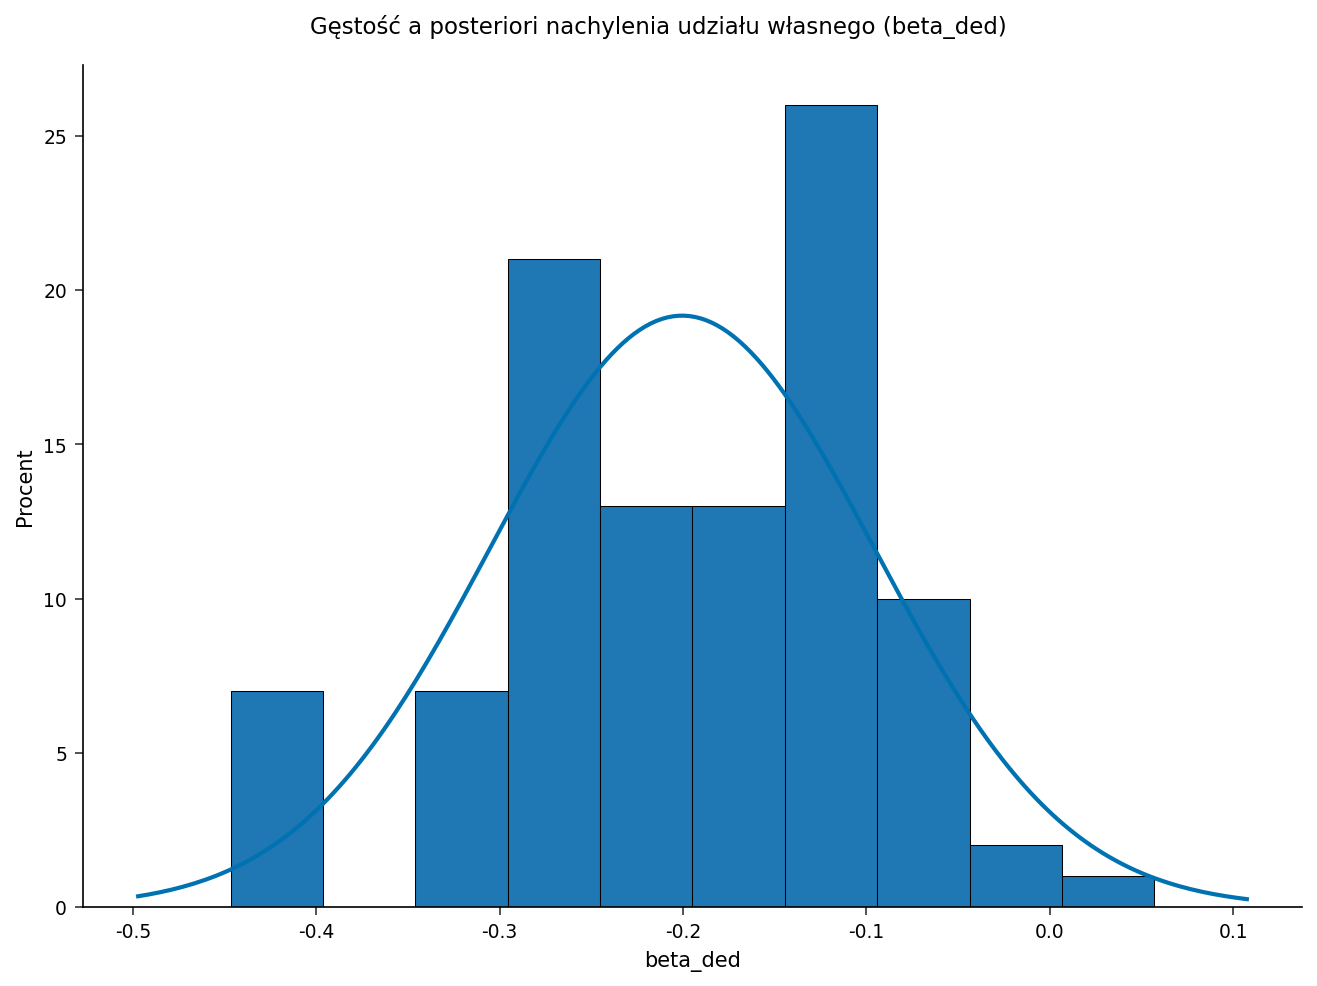

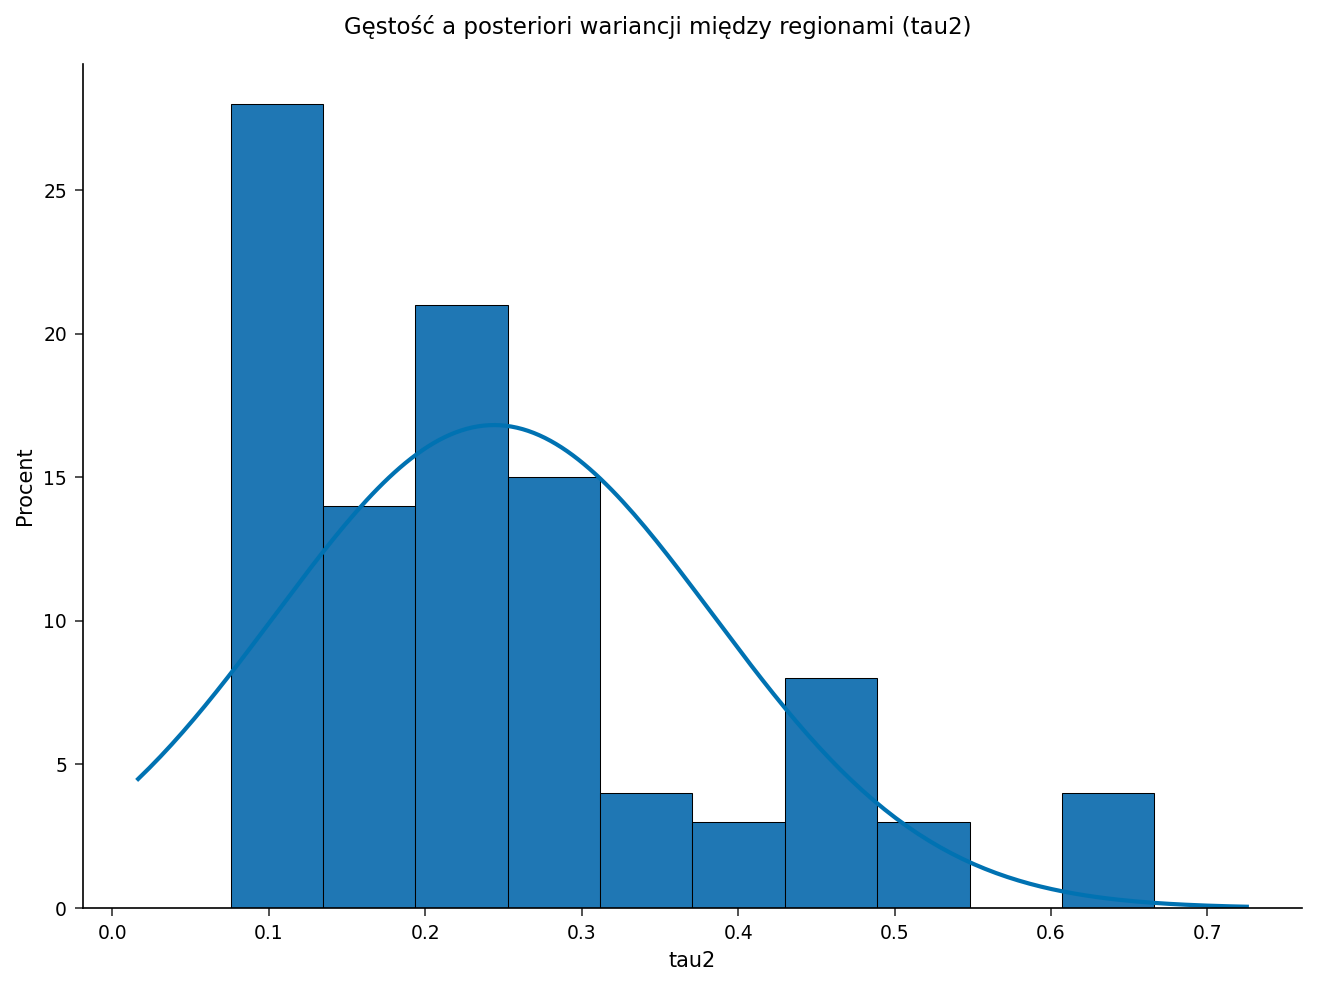

In [6]:
/* region_sd zostało dodane do post w widoku danych z Kroku 5 */
DANE post2;
    USTAW post;
    region_sd = sqrt(tau2);
WYKONAJ;

/* Ślad bazowej log-częstości */
PROCEDURA SGPLOT DANE=post2;
    SERIES x=iter y=beta0;
    TYTUŁ 'Ślad beta0 (zapisane losowania a posteriori)';
    XAXIS ETYKIETA='Zapisana iteracja';
    YAXIS ETYKIETA='beta0';
WYKONAJ;

/* Gęstość a posteriori nachylenia udziału własnego */
PROCEDURA SGPLOT DANE=post2;
    HISTOGRAM beta_ded;
    DENSITY   beta_ded;
    TYTUŁ 'Gęstość a posteriori nachylenia udziału własnego (beta_ded)';
    XAXIS ETYKIETA='beta_ded';
    YAXIS ETYKIETA='Procent';
WYKONAJ;

/* Gęstość a posteriori wariancji między regionami */
PROCEDURA SGPLOT DANE=post2;
    HISTOGRAM tau2;
    DENSITY   tau2;
    TYTUŁ 'Gęstość a posteriori wariancji między regionami (tau2)';
    XAXIS ETYKIETA='tau2';
    YAXIS ETYKIETA='Procent';
WYKONAJ;

## Interpretacja wyników

**Co dostarczył model:**

- **Odtworzona struktura.** Efekty regionalne a posteriori (`post_mean_u`) podążają za zadaną prawdą (`true_eff`) co do znaku i kolejności: region 5 (prawdziwe +0,40) jest najwyższy przy +0,36, region 4 (prawdziwe -0,30) jest najniższy przy -0,70, a region 1 (prawdziwe +0,05) leży blisko środka przy +0,20. Nachylenie udziału własnego `beta_ded` wynosi -0,13 (ujemne, zgodnie ze specyfikacją procesu generującego dane, choć skurczone w stronę zera przez małą próbę 96 polis), a `beta0` odtwarza bazową log-częstość 0,43 - dowód, że hierarchiczna wiarygodność Poissona i offset ekspozycji zostały poprawnie określone.
- **Częściowe pulowanie w akcji.** Porównaj skurczoną `relativity` z Kroku 4 z surowymi częstościami z Kroku 2. Surowa częstość regionu 5 wynosząca 3,41 jest ściągana do relatywności 1,43, a surowa wartość 0,45 regionu 4 podnosi się do relatywności 0,49 - cienkie regiony są okiełznane w stronę centrum portfela i niosą **najszersze przedziały wiarygodności**, dokładnie takie zachowanie, jakiego oczekuje aktuariusz: nie przepłacaj ani nie niedoszacowuj terytorium na podstawie garstki losowych szkód.
- **Skwantyfikowana niepewność.** Rozkład a posteriori `sqrt(tau2)` (średnia około 0,48) mierzy, ile prawdziwej heterogeniczności między regionami pozostaje po uwzględnieniu struktury udziału własnego i ekspozycji - bezpośredni wkład do pewności relatywności terytorialnej oraz do niepewności kapitału/rezerw.
- **Diagnostyka i dopasowanie modelu.** Zgłoszone **DIC wynosi 246,7**, miara porównawcza tej specyfikacji hierarchicznej wobec prostszych modeli w pełni poolowanych lub w pełni niepoolowanych. Efektywne liczności próby są umiarkowane (`beta_ded` blisko 525, efekty losowe i `beta0` w dziesiątkach), a **diagnostyka Gewekego sygnalizuje wszystkie trzy monitorowane parametry** - wykres śladu pokazuje `beta0` dryfujące w górę w pierwszych 100 zapisanych losowaniach. Przy zaledwie 96 latach polisowych i krótkich łańcuchach w trybie bez licencji ten brak zbieżności jest oczekiwany; produkcyjne uruchomienie wydłużyłoby rozgrzewkę (burn-in) i próbkowanie, a być może przeparametryzowałoby model, zanim polegano by na przedziałach.

**Dlaczego bayesowsko:** Relatywności częstości trafiają bezpośrednio do wyceny, a regulatorzy coraz częściej oczekują kwantyfikacji niepewności. PROC MCMC produkuje *cały rozkład a posteriori* dla każdego regionu, więc zakład ubezpieczeń może stwierdzić, na przykład: "relatywność częstości regionu 4 ma 95% przedział wiarygodności wokół swojej średniej a posteriori 0,49" - stwierdzenie, którego klasyczne estymaty punktowe nie mogą wyrazić, i które jest najcenniejsze właśnie dla małych, ubogich w dane terytoriów.